# Model 1a: FO permeate flux (long-term, replicate 1) - RandomForest regression

Predicts Jw from process sensor features (time, conductivities, temps, TMP).
Replicates Fig. 6A of the paper.

In [2]:
import pandas as pd, numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
df = pd.read_csv("data/fo_flux_longterm_rep1_full.csv")
features = ["time_min","feed_cond_mScm","draw_cond_mScm","feed_temp_C","draw_temp_C","RO_TMP_bar","FO_TMP_bar"]
X = df[features].values
y = df["Jw"].values

In [4]:
# chronological train/test split (mimics forecasting future flux from early operation)
n = len(df)
split = int(n*0.75)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
t_train, t_test = df["time_min"].values[:split], df["time_min"].values[split:]

In [5]:
model = RandomForestRegressor(n_estimators=400, max_depth=8, min_samples_leaf=3, random_state=42)
model.fit(X_train, y_train)
pred_test = model.predict(X_test)
pred_train = model.predict(X_train)

In [6]:
r2_test = r2_score(y_test, pred_test)
rmse_test = mean_squared_error(y_test, pred_test)**0.5
r2_train = r2_score(y_train, pred_train)
rmse_train = mean_squared_error(y_train, pred_train)**0.5

In [7]:
# 5-fold CV on full data for a less biased performance estimate
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(RandomForestRegressor(n_estimators=400, max_depth=8, min_samples_leaf=3, random_state=42),
                         X, y, cv=kf, scoring="r2")

In [8]:
print(f"Chronological split -> Train R2={r2_train:.3f} RMSE={rmse_train:.3f} | Test R2={r2_test:.3f} RMSE={rmse_test:.3f}")
print(f"5-fold CV R2: {cv_r2} mean={cv_r2.mean():.3f}")

Chronological split -> Train R2=0.859 RMSE=0.088 | Test R2=-0.045 RMSE=0.326
5-fold CV R2: [0.67230783 0.80036673 0.76338277 0.85175801 0.73545978] mean=0.765


In [9]:
# feature importance
imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("Feature importances:\n", imp)

Feature importances:
 FO_TMP_bar        0.390590
feed_cond_mScm    0.200280
draw_cond_mScm    0.171909
time_min          0.097930
draw_temp_C       0.089096
feed_temp_C       0.031622
RO_TMP_bar        0.018574
dtype: float64


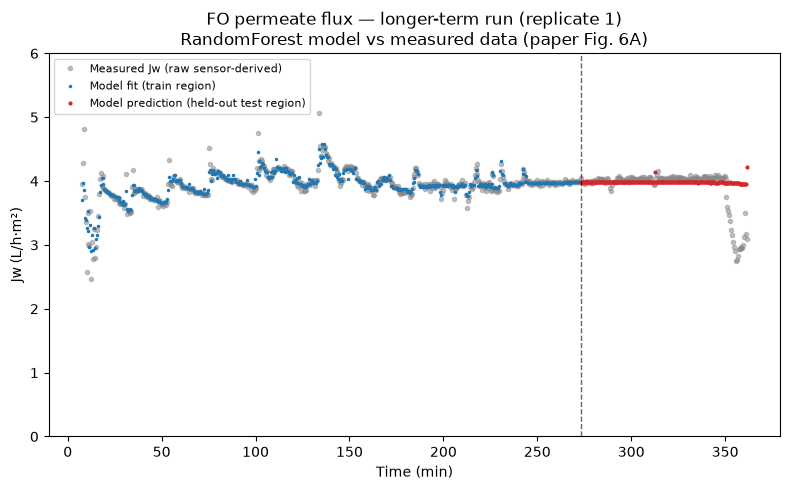

saved plot


In [11]:
# Plot: actual vs predicted flux over time (replicates Fig 6A)
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(df["time_min"], y, "o", ms=3, color="#888", alpha=0.5, label="Measured Jw (raw sensor-derived)")
ax.plot(t_train, pred_train, ".", ms=3, color="#1f77b4", label="Model fit (train region)")
ax.plot(t_test, pred_test, ".", ms=4, color="#d62728", label="Model prediction (held-out test region)")
ax.axvline(t_test[0], color="k", linestyle="--", lw=1, alpha=0.6)
ax.set_xlabel("Time (min)")
ax.set_ylabel("Jw (L/h·m²)")
ax.set_title("FO permeate flux — longer-term run (replicate 1)\nRandomForest model vs measured data (paper Fig. 6A)")
ax.legend(fontsize=8)
ax.set_ylim(0,6)
plt.tight_layout()
plt.savefig("plots/model1a_fo_flux_longterm.png", dpi=150)
plt.show()
print("saved plot")

In [13]:
# save model + metrics
import joblib
joblib.dump(model, "models/fo_flux_longterm_rf.joblib")
with open("models/metrics_fo_flux_longterm.txt","w") as f:
    f.write(f"Chronological split -> Train R2={r2_train:.3f} RMSE={rmse_train:.3f} | Test R2={r2_test:.3f} RMSE={rmse_test:.3f}\n")
    f.write(f"5-fold CV R2: {list(cv_r2)} mean={cv_r2.mean():.3f}\n")
    f.write(f"Feature importances:\n{imp.to_string()}\n")
    f.write(f"Paper reported range: 3.9-4.1 L/h.m2 (stable). Data mean={df['Jw'].mean():.2f}, std={df['Jw'].std():.2f}\n")